# Whakaari Cause–Trigger Analysis

This notebook runs the Cause–Trigger algorithm on the Whakaari dataset using three causal-discovery backends:

1. **HMML** — baseline.
2. **PCMCI** — lagged causal-discovery sensitivity backend.
3. **PCMCI+** — lagged + contemporaneous causal-discovery backend.

## 1. Imports and paths

In [29]:
from pathlib import Path
import sys
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "whakaari"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_whakaari import *

EVENT_TIME = pd.Timestamp("2019-12-09 01:11:00", tz="UTC")
WHAKAARI_PATH = DATA_DIR / "whakaari_final.csv"

In [ ]:
X_full = load_model_frame(WHAKAARI_PATH)

CASE_START = EVENT_TIME - pd.Timedelta(days=14)
CASE_END = EVENT_TIME + pd.Timedelta(days=3)

X = X_full.loc[CASE_START:CASE_END].copy()

display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,334,8,2019-11-25 02:00:00+00:00,2019-12-09 13:00:00+00:00,None,effect_tremor_5_15_scaled,-2.89423,0.691119,0.53608,2.320802,0.883426,0.444653,334


## 2. Automatic parameter selection, Main configuration and split check

In [ ]:
from parameter_extraction import find_parameters

selected_distribution, selected_lag = find_parameters(
    X=X,
    target_series=X[EFFECT],
    max_lags=12,
    criterion="aic",
    fallback_lag=1,
    fallback_distribution="gaussian",
)

pd.DataFrame([{
    "effect": EFFECT,
    "selected_lag": int(selected_lag),
    "selected_distribution": selected_distribution,
    "lag_method": "VAR-AIC",
    "max_lags": 6,
}])

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,effect,selected_lag,selected_distribution,lag_method,max_lags
0,effect_tremor_5_15_scaled,3,gaussian,VAR-AIC,6


In [ ]:
workflow = WhakaariWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    alpha=0.05,
    selected_lag=int(selected_lag),
    max_lags=12,
    min_I1_length=48,
    min_I2_length=48,
    distribution=selected_distribution,
    parameter_source="automatic",
)

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,boundary_split
0,effect_tremor_5_15_scaled,None,None,None,None,None,None,None,2019-12-09 01:11:00+00:00,None,None


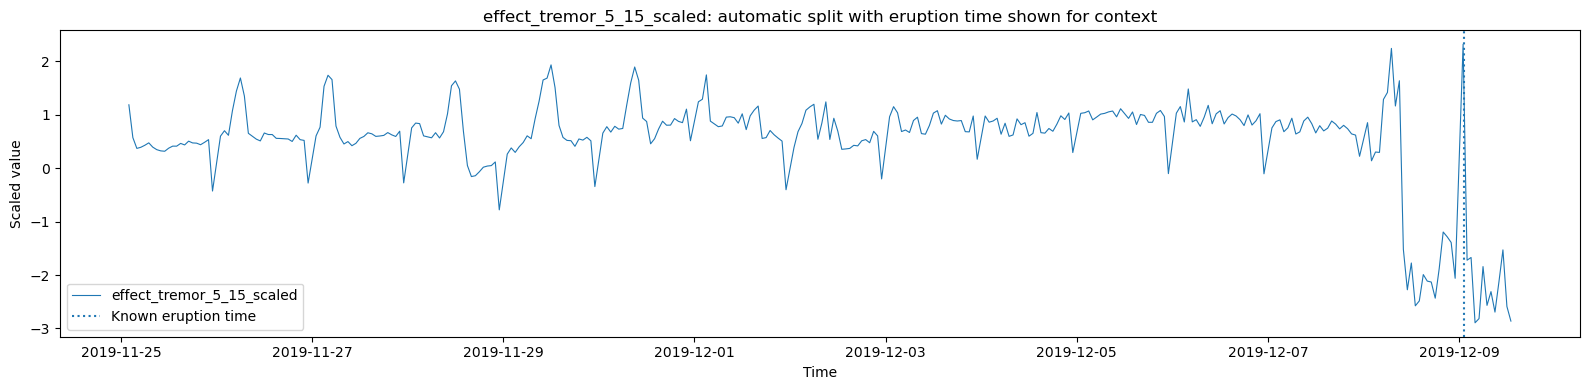

In [33]:
paper_split = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
    split_method="paper_suffix",
    split_direction="absolute_mean",
    split_response_length=None,
)

display(pd.DataFrame([paper_split]))

plot_effect_with_split(
    X,
    EFFECT,
    paper_split,
    event_time=workflow.event_time,
)

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,boundary_split
0,effect_tremor_5_15_scaled,None,None,None,None,None,None,None,2019-12-09 01:11:00+00:00,None,None


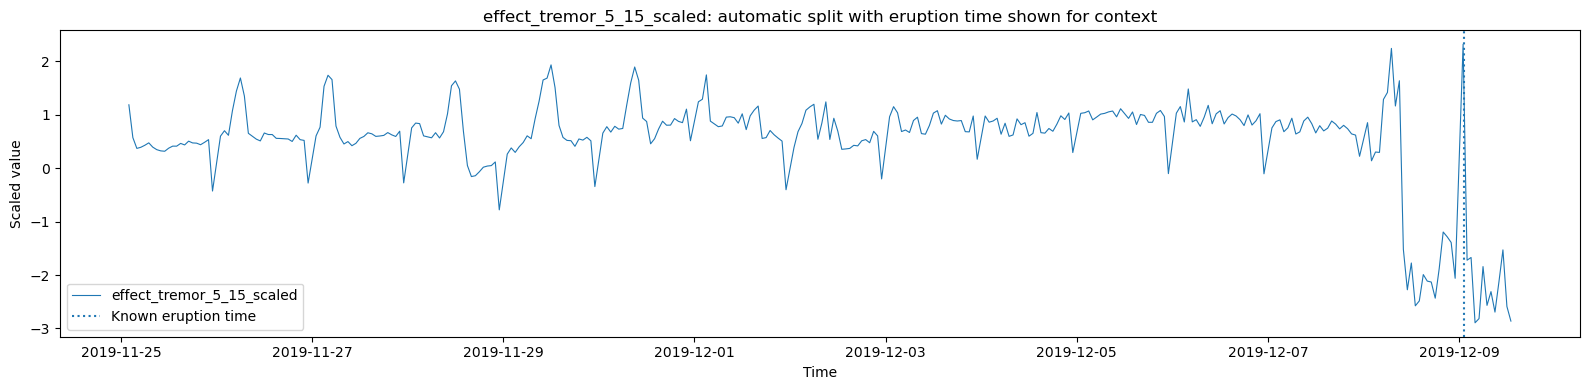

In [34]:
main_split = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
    split_method=workflow.split_method,
    split_direction=workflow.split_direction,
    split_response_length=workflow.split_response_length,
    split_search_start=workflow.split_search_start,
    split_search_end=workflow.split_search_end,
    lag=workflow.selected_lag,
)

display(pd.DataFrame([main_split]))

plot_effect_with_split(
    X,
    EFFECT,
    main_split,
    event_time=workflow.event_time,
)

## 3. Main run

HMML is the baseline. PCMCI/PCMCI+ are extensions.

In [35]:
results, comparison, diagnostics = run_suite(
    X,
    workflow,
    lag=workflow.selected_lag,
    distribution=workflow.distribution,
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


In [36]:
#display(compact_comparison(comparison))
display(comparison)

,run,effect,backend,parameter_source,configured_lags,configured_distribution,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,...,target_abs_mean_difference,B1,B2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,stop_reason
0,hmml_backend_beta,effect_tremor_5_15_scaled,hmml,automatic_hmml_lag3_gaussian_backend_beta,3,gaussian,backend,None,None,None,...,None,None,[],False,[],[],"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled]",[],0,No valid I1/I2 split found under split_method=...
1,pcmci_ridge,effect_tremor_5_15_scaled,pcmci,automatic_pcmci_lag3_gaussian_ridge_refit,3,gaussian,refit,ridge,None,None,...,None,None,[],False,[],[],[ratio_4p5_8_over_8_16_scaled],[],0,No valid I1/I2 split found under split_method=...
2,pcmci_adaptive_lasso,effect_tremor_5_15_scaled,pcmci,automatic_pcmci_lag3_gaussian_adaptive_lasso_r...,3,gaussian,refit,adaptive_lasso,None,None,...,None,None,[],False,[],[],[ratio_4p5_8_over_8_16_scaled],[],0,No valid I1/I2 split found under split_method=...
3,pcmci_plus_ridge,effect_tremor_5_15_scaled,pcmci_plus,automatic_pcmci_plus_lag3_gaussian_ridge_refit,3,gaussian,refit,ridge,None,None,...,None,None,[],False,[],[],[hydro_2_5_scaled],[],0,No valid I1/I2 split found under split_method=...
4,pcmci_plus_adaptive_lasso,effect_tremor_5_15_scaled,pcmci_plus,automatic_pcmci_plus_lag3_gaussian_adaptive_la...,3,gaussian,refit,adaptive_lasso,None,None,...,None,None,[],False,[],[],[hydro_2_5_scaled],[],0,No valid I1/I2 split found under split_method=...


In [37]:
#display(compact_diagnostics(diagnostics))
display(diagnostics)

""


### PCMCI+ run

In [38]:
result_tau0, diag_tau0, row_tau0 = run_one(
    X,
    workflow,
    run_name="pcmci_plus_tau0_ridge",
    backend="pcmci_plus",
    refit_method="ridge",
    parameter_source="automatic_pcmci_plus_tau0_ridge",
    use_contemporaneous_triggers=True,
)

## 4. Sensitivity check

In [39]:
sensitivity = run_sensitivity_grid(
    X,
    workflow,
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

KeyboardInterrupt: 

In [ ]:
#display(compact_sensitivity(sensitivity))
display(sensitivity)

In [ ]:
display(accepted_sensitivity_rows(sensitivity))